# XAVIER INITIALIZATION



In this reading assignment, you will learn about the Xavier initialisation techniques used on a neural network.

## Prerequisites:
To start with Xavier Initialisation, you must have knowledge about:
- Weights in a Neuron
- Forward propagations on a neural network.
- Activations functions used on a neural network.
- Random Initialization
- Zeros and ones Initialization

## Learning Objectives:
By the end of the lesson the learners will be able to:
- Introduce the concepts of Xavier initialization
- Understand the problems of random initialization






## **Problems with Random Initialization**


As we discussed in the previous chapter Random initialization is way better than zeros initialization and also  solves the problem of symmetry, however initializing with random weight may make network’s to learn slowly which causes convergence problem,vanishing and exploding gradients, issues and instabilities with training.






Consider a part of neural network as shown below.



<p>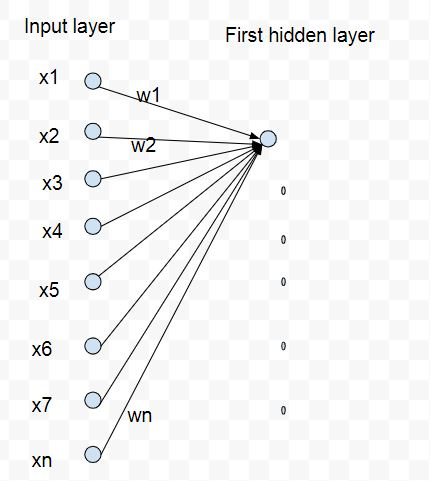</p>


The input output relationship considering only first neuron in first hidden layer is
$$ z=w_1x_1+w_2x_2+....+w_nx_n$$
where, n is the number of neurons coming from input layers to first neuron in first hidden layer.


We don't want the value of z to be either too large or too small as this would cause the output of of sigmoid function to lie in dead zone (the region where the learning is too slow).

1.   if we intialize with random weight, the behaviour produces by the random weight during forward pass will generates a very large loss because it does not match the underlying  data distribution

2.   If weights are initialized with very high values For a large number of neurons n, there will be a lot of $w_ix_i$ terms. They would cause y to be larger as the addition of lots of those $x_iw_i$ would cause the value of x to be large and hence cause exploding gradient problem.

3. If weights are initialized with low values it gets mapped to 0 and hence cause vanishing gradient problem..




# Xavier Initialization


Let's dig deeper in order to find the best way for the initialization of the weights. Well, the objective is to find the best sets of weights that provides faster convergence effectively during training. For faster convergence, the distribution of signal should be similar across all the neurons. That means, we want the variance to remain same while passing through each layer. This will keep signal from exploding to high value or vanish to zero. We need to initialize the weights in such a way that the variance remains same across layers. This is the main principle based on which $Xavier$ $initialization$ is presented. **This technique tries to make the variance of output layer to be equal to the variance of it's inputs while passing through each layers.** We have already discussed in the previous section if the weights in a network start too small, then the signal shrinks as it passes through each layer until it's too tiny to be useful. Similary, if the weights start too large, then the signal grows as it passes through each layer until it's too massive to be useful. Xavier initialization makes sure that the weights are just right to keep the signal in reasonable range of values through many layers.


## Mathmatical Formulation


We want the weights to remain in the specific range i.e, we want output to have same variance as the inputs;
$$Var(y)=Var(x_i)$$
The variance of product of two variables a and b is

$$Var(ab)=(E[a])^2Var(b)+(E[b])^2Var(a)+Var(a)Var(b)$$
Where, E is expected mean

So, $$Var(w_ix_i)=(E[w_i])^2Var(x_i)+(E[x_i])^2Var(w_i)+Var(x_i)Var(w_i)$$

For gaussian distribution, mean (E) of the weights and inputs are zero. The above equation simplifies to
$$Var(w_ix_i)=Var(w_i)Var(x_i)$$
If the distribution of x_i and w_i are identical then,
$$Var(y)=Var(w_1x_1+w_2x_2+...+w_nx_n)=nVar(w_i)Var(x_i)$$


Now for input and output distribution to be similar i.e,
$Var(y)=Var(x_i)$, we have $nVar(w_i)Var(x_i)=Var(x_i)$
This implies,
$$nVar(w_i)=1$$
$$Var(w_i)=\frac{1}{n}=\frac{1}{n_{in}}$$
Standard deviation ($\sigma$)=$\sqrt{Var}=\sqrt{\frac{1}{n_{in}}}=\sqrt{\frac{1}{size^{[l-1]}}}$
Where,$n_{in}$ is the number of input neurons/ weights coming to the neuron.


So the above relationship shows that for Xavier initialization, we need to pick the weights from a Gaussian(normal) distribution with zero mean and a variance of 1/N, where N specifies the number of input neurons. Therefore, the initialization is dependent on the number of input neurons. Moreover, the initialization occurs on a per-layer basis. That mean we have to initialize for each layers separately. Though the above expression considered only the input neurons, the authors have considered both the number of neurons in input layer as well as neurons in output layer which will be discussed later.


Upto this point we understood the mathematics behind the Xavier initialization. Lets now understand it logically. The output of first layer defined as
$$z=x_1w_1+x_2w_2+....+x_nw_n$$
We don't want the output (z) to be either too big, or too small.
For very large number of input neurons (n), we want the weights to be smaller so that z will have median value. Since we are adding a lot of $x_iw_i$, we want each of them to be smaller. For a large number of inputs, if the weights are all big then, we would end up with a large value of z. So we need to control weights. We divide weights selected from normal distribution by $\sqrt{n}$, so the bigger the number of input neurons we have, that means bigger is the number with which we are dividing the weight $w_i$ by. So we are performing initialization not by taking data from normal distribution but also considering the number of neurons.


Xavier and Yoshua, in their paper "Understanding the difficulty of training deep feedforward neural networks", however, have extended the expression of variance. They have taken the average number of input neurons $N_{in}$ and the output numbers $N_{out}$ for computing variance.
$$Var(w_i)=\frac{1}{N_{avg}}=\frac{1}{\frac{N_{in}+N_{out}}{2}}=\frac{2}{N_{in}+N_{out}}$$

Standard deviation is
$$\sigma=\sqrt{\frac{2}{N_{in}+N_{out}}}=\sqrt{\frac{2}{size^{[l-1]}+size^{[l]}}}$$


By considering the number of neurons at the output neurons we are preserving the backpropagated signals as well. It is to be noted that both of these concepts or technique works well.




## Effects of Xavier Initialization


<center>
<figure>


<p>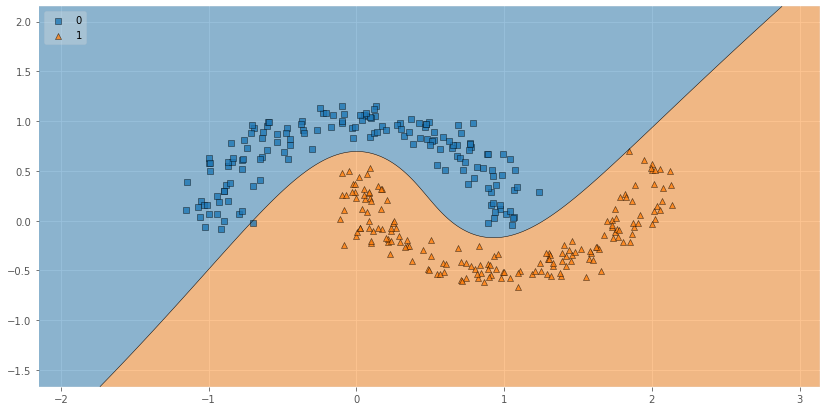</p>


<p>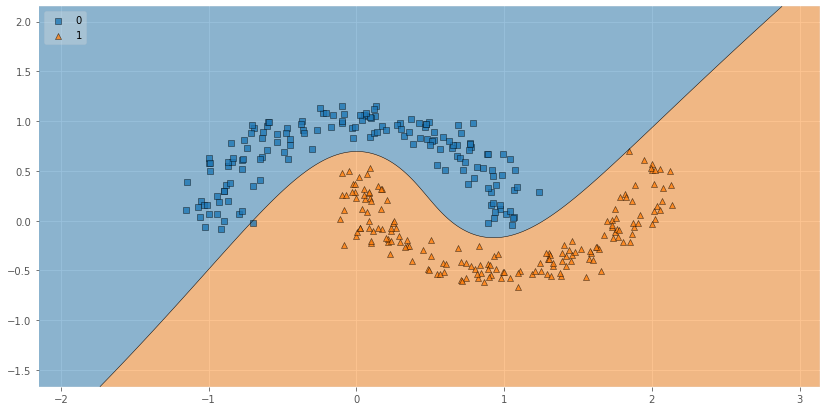</p>
<figcaption align="center">Figure 2: Effects of Xavier Initialization</figcaption>
</figure>
</center>


## Takeaways
The takeaways from the lesson are:
>* Xavier initialization tries to make the variance remains the same across the layers
>* How Xavier initialization solves the problem of random initialization.
>* Problems with random initialization




# REFERENCES




## Articles


[Xavier Initailization, SRC:Medium](https://medium.com/@prateekvishnu/xavier-and-he-normal-he-et-al-initialization-8e3d7a087528)




## Papers
[Understanding the difficulty of training deep feedforward neural networks](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)
